# Занятие 33. Переобучение и валидация

Модель нужна не для запоминания таблицы, а для работы с новыми объектами. Сегодня разберём, как отличить настоящую закономерность от удачного совпадения на известных данных.


## 1. Три состояния модели

- **Недообучение:** модель слишком проста; велики ошибки и на train, и на новых данных.
- **Хорошее обобщение:** ошибки невелики и близки.
- **Переобучение:** train почти запомнен, но validation заметно хуже.

Низкая train-ошибка сама по себе ничего не гарантирует.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.DataFrame({
 'модель':['слишком простая','разумная','слишком сложная'],
 'train error':[0.35,0.12,0.01],
 'validation error':[0.38,0.15,0.33]
})
summary


,модель,train error,validation error
0,слишком простая,0.35,0.38
1,разумная,0.12,0.15
2,слишком сложная,0.01,0.33


## 2. Откуда берётся переобучение

Модель учит и закономерность, и случайный шум. Риск растёт, если:

- данных мало;
- признаков или степеней свободы много;
- модель слишком гибкая;
- долго подбирали варианты по одной validation-выборке;
- произошла утечка.

Регуляризация, ограничение сложности и новые данные помогают, но не заменяют честную проверку.


## 3. Смещение и разброс *

Слишком простая модель имеет высокое смещение: она систематически пропускает закономерность. Слишком гибкая имеет высокий разброс: заметно меняется при небольшом изменении train.

Validation помогает найти компромисс. Это качественная идея; формальный вывод не требуется.


## 4. Параметры и гиперпараметры

**Параметры** модель узнаёт из train: например, коэффициенты регрессии.

**Гиперпараметры** задаёт исследователь: степень полинома, сила регуляризации, а в будущих темах — глубина дерева. Их выбирают по validation или кросс-валидации, но не по test.


## 5. Многократный перебор тоже переобучает

Если проверить сотни идей на одной validation-выборке, случайно найдётся удачная. Исследователь постепенно подстраивается под validation так же, как модель под train.

Поэтому ограничивают хаотичный перебор, используют CV и сохраняют независимый test.


## 6. Train, validation и test

Train обучает параметры. Validation выбирает гиперпараметры и идеи. Test открывается после выбора.

Аналогия: **train** — учебник, на котором учимся; **validation** — пробник, по которому подбираем стратегию; **test** — контрольная, которую открываем один раз в конце.

Если мы посмотрели test, изменили степень полинома и снова посмотрели test, то фактически начали обучаться на test. Его оценка становится оптимистичной.


## 7. Одно разбиение и повторная проверка

Одна validation-оценка зависит от случайного состава объектов. Повторные разбиения или CV показывают устойчивость вывода.

Среднее без отдельных значений недостаточно: две модели с одинаковым средним могут иметь разный разброс по fold.


## 8. Validation curve

Validation curve показывает качество при разных значениях одного гиперпараметра.

- слева модель может быть слишком простой;
- в середине — оптимальная сложность;
- справа train улучшается, а validation ухудшается: начинается переобучение.


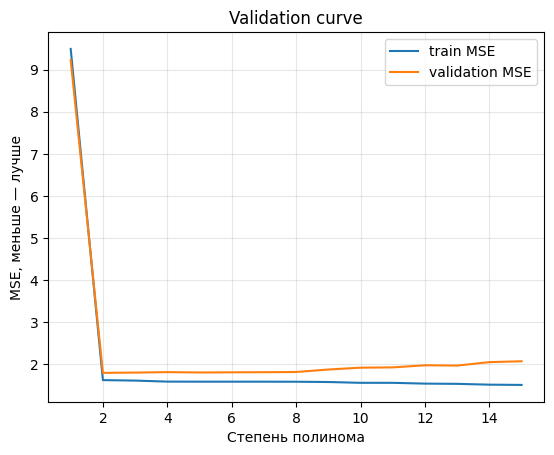

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rng=np.random.default_rng(42)
X=np.linspace(-3,3,180).reshape(-1,1)
y=X[:,0]**2+rng.normal(0,1.5,len(X))
X_tr,X_val,y_tr,y_val=train_test_split(X,y,test_size=.3,random_state=42)
degrees=range(1,16); train_scores=[]; val_scores=[]
for degree in degrees:
 poly=PolynomialFeatures(degree=degree,include_bias=False)
 Xtr_poly=poly.fit_transform(X_tr); Xval_poly=poly.transform(X_val)
 m=LinearRegression().fit(Xtr_poly,y_tr)
 train_scores.append(mean_squared_error(y_tr,m.predict(Xtr_poly)))
 val_scores.append(mean_squared_error(y_val,m.predict(Xval_poly)))
plt.plot(degrees,train_scores,label='train MSE'); plt.plot(degrees,val_scores,label='validation MSE')
plt.xlabel('Степень полинома'); plt.ylabel('MSE, меньше — лучше'); plt.title('Validation curve')
plt.grid(alpha=.3); plt.legend(); plt.show()


## 9. Learning curve

Learning curve показывает качество при росте размера train.

- Обе кривые плохи и близки — модель, вероятно, слишком проста.
- Train хорош, validation заметно хуже — переобучение; дополнительные данные могут помочь.
- Кривые почти сошлись — добавление данных в наблюдаемом диапазоне уже мало помогает именно этой модели.


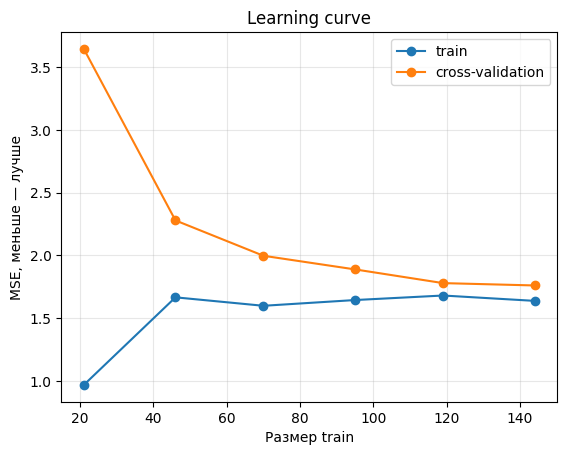

In [3]:
from sklearn.model_selection import learning_curve, KFold

poly5=PolynomialFeatures(degree=5,include_bias=False)
X_poly5=poly5.fit_transform(X)  # преобразование не обучает статистики данных
learning_cv=KFold(n_splits=5,shuffle=True,random_state=42)
sizes,tr,va=learning_curve(
 LinearRegression(),X_poly5,y,cv=learning_cv,
 train_sizes=np.linspace(.15,1,6),scoring='neg_mean_squared_error',
 shuffle=True,random_state=42
)
tr=-tr; va=-va
plt.plot(sizes,tr.mean(axis=1),marker='o',label='train')
plt.plot(sizes,va.mean(axis=1),marker='o',label='cross-validation')
plt.xlabel('Размер train'); plt.ylabel('MSE, меньше — лучше'); plt.title('Learning curve')
plt.grid(alpha=.3); plt.legend(); plt.show()


## 10. K-fold cross-validation

Данные делят на $k$ частей. Модель обучают $k$ раз: каждый раз одна часть служит validation, остальные — train. Затем метрики усредняют.

Плюсы: оценка устойчивее одного разбиения. Минусы: обучение дороже, а неправильная схема разбиения всё равно даст неправильный ответ.


In [4]:
from sklearn.model_selection import cross_validate, KFold

cv=KFold(n_splits=5,shuffle=True,random_state=42)
result=cross_validate(LinearRegression(),X_poly5,y,cv=cv,scoring='neg_mean_squared_error',return_train_score=True)
print('Validation scores:',result['test_score'].round(3))
print('Средняя MSE:',round(-result['test_score'].mean(),3))
print('Разброс значений по fold:',round(result['test_score'].std(),3))


Validation scores: [-2.186 -1.48  -2.434 -1.365 -1.337]
Средняя MSE: 1.76
Разброс значений по fold: 0.458


## 11. Стратификация

При редком классе случайный fold может получить слишком мало положительных объектов. StratifiedKFold сохраняет примерно одинаковые доли классов.

Стратификация не исправляет дисбаланс и не заменяет подходящую метрику; она лишь делает сравнение fold устойчивее.


## 12. Схема разбиения зависит от данных

- `StratifiedKFold` сохраняет доли классов.
- `GroupKFold` не разрывает связанные группы, например фотографии одного пациента.
- `TimeSeriesSplit` обучает на прошлом и проверяет на будущем.

Случайное перемешивание временного ряда или попадание одного человека в train и validation создаёт утечку.


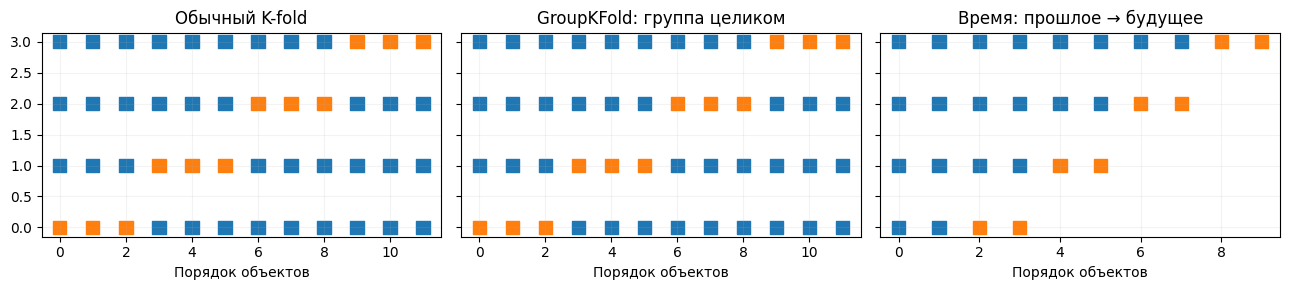

In [5]:
# Схемы разбиения: синий — train, оранжевый — validation.
fig,axes=plt.subplots(1,3,figsize=(13,3),sharey=True)
for fold in range(4):
 colors=['tab:blue']*12
 for j in range(fold*3,(fold+1)*3): colors[j]='tab:orange'
 axes[0].scatter(range(12),[fold]*12,c=colors,marker='s',s=90)
axes[0].set_title('Обычный K-fold')

groups=np.repeat(range(4),3)
for fold in range(4):
 axes[1].scatter(range(12),[fold]*12,c=np.where(groups==fold,'tab:orange','tab:blue'),marker='s',s=90)
axes[1].set_title('GroupKFold: группа целиком')

for fold,end in enumerate([4,6,8,10]):
 axes[2].scatter(range(end),[fold]*end,c=['tab:blue']*(end-2)+['tab:orange']*2,marker='s',s=90)
axes[2].set_title('Время: прошлое → будущее')
for ax in axes: ax.set_xlabel('Порядок объектов'); ax.grid(alpha=.15)
plt.tight_layout(); plt.show()


## 13. Предобработка внутри каждого fold

Медиана, scaler, отбор признаков и кодировщик категорий должны обучаться только на train-части текущего fold. Если сначала преобразовать всю таблицу, validation повлияет на обучение.

На практике последовательность преобразований объединяют в воспроизводимый процесс. Внутри каждого fold порядок один и тот же:

`fit preprocessing на fold-train → transform fold-train/fold-validation → fit model → score`.

Важно понимать принцип: каждый fold изображает новые, ещё не увиденные данные.


## 14. Типичные утечки внутри CV

Нельзя до CV по всей таблице выбирать признаки по корреляции с целью, заполнять пропуски или масштабировать. Иначе validation-fold влияет на обученные параметры.

Безопасный вопрос к любой операции: «узнаёт ли она что-нибудь из данных?» Если да, её fit должен происходить внутри каждого fold.


## 15. Grid search

Grid search перебирает сетку гиперпараметров и оценивает каждый вариант кросс-валидацией. Чем больше вариантов мы перебираем, тем сильнее можем случайно подстроиться под CV.

Поэтому test остаётся отдельно. *Вложенная валидация* использует внешний цикл для оценки и внутренний для настройки; это полезная, но факультативная идея.


## 16. Вложенная валидация *

Во внутреннем цикле выбирают гиперпараметры, во внешнем оценивают весь процесс выбора. Это защищает оценку при большом числе настроек.

Метод дорогой и чаще нужен для строгого исследования; в учебном проекте достаточно понимать различие между настройкой и независимой оценкой.


## 17. Финальный протокол

1. Отделить test подходящим способом.
2. На оставшихся данных сравнивать идеи одним CV-протоколом.
3. Выбрать модель и гиперпараметры.
4. Переобучить выбранный процесс на всех доступных train+validation данных.
5. Один раз оценить на test.
6. Сообщить среднее, разброс и ограничения.

> **Главная мысль.** Валидация проверяет не только алгоритм, но и честность всего способа получения модели.
